# FunnyBirds CBM — Renderer-Based Part Swap (Experiment 1)

**Hypothesis (backwash):** concept neuron activations *z_C* carry species-identity
signal beyond merely encoding which part variant is present.

**This notebook tests the mechanism using the FunnyBirds 3-D renderer:**
for every sampled test image of species A, re-render it with one body part swapped
to species B's variant — same camera, lighting, and background, **only the part
changes** — then run both original and counterfactual through the full CBM.

**Three measurements per swap:**
1. **Prediction shift** — does P(species B) rise after the swap? `shift_B > 0` = leakage.
2. **Delta-z** — did the concept bottleneck detect the part change?
   - `delta_z_old < 0`: old concept dim fell  
   - `delta_z_new > 0`: new concept dim rose
3. **Deletion control** — render with part removed entirely; this is the ceiling.
   If `|shift_B_swap| ≈ deletion_drop`, the new part provides no signal.

**Symmetric leakage score:**  
`leakage_sym = 0.5 × (shift_B_forward + shift_A_backward)`

**Order:** primary experiment on `tail` (most discriminative in variance analyses),
then extended to all 5 body parts.

Renderer: https://github.com/visinf/funnybirds (see Cell 19 for setup).
Data loading follows `fb_recallv2.ipynb` exactly.

In [45]:
import gc
import io
import json
import random
import subprocess
import sys
import time
from base64 import decodebytes
from itertools import combinations
from pathlib import Path

import requests
%matplotlib inline
import matplotlib
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from matplotlib.lines import Line2D
import numpy as np
import pandas as pd
from PIL import Image
from scipy import stats
import torch
import torch.nn as nn
from torchvision import models, transforms
try:
    from tqdm.notebook import tqdm
except ImportError:
    from tqdm import tqdm

## 0. Paths and configuration

In [2]:
ROOT = Path('/scratch/network/cr7998/cv_emergence_project')
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

FB        = ROOT / 'data'     / 'FunnyBirds'
CBM_FEATS = ROOT / 'features' / 'resnet50_cbm_funnybirds'
CBM_CKPT  = ROOT / 'checkpoints_funnybirds' / 'cbm_funnybirds.pth'

# Clone the renderer: git clone https://github.com/visinf/funnybirds.git
# then: cd funnybirds/render && npm install
RENDERER_DIR = ROOT.parent / 'funnybirds' / 'render'  # adjust if cloned elsewhere

assert FB.exists(),        f'Missing FunnyBirds data: {FB}'
assert CBM_FEATS.exists(), f'Missing CBM features: {CBM_FEATS}'
assert CBM_CKPT.exists(),  f'Missing CBM checkpoint: {CBM_CKPT}'

N_SPECIES  = 50
N_CONCEPTS = 26

# ── Experiment limits ─────────────────────────────────────────────────────────
# Increase for more power; decrease during development.
# Estimated runtime at defaults: ~40 min tail + ~2 h all parts (CPU renderer).
MAX_IMGS_PER_SPECIES = 5    # test images per species per swap direction
MAX_PAIRS_PER_PART   = 100  # None = all valid pairs; 100 keeps runtime tractable

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'device:             {device}')
print(f'CBM checkpoint:     {CBM_CKPT}')
print(f'Renderer dir:       {RENDERER_DIR}  (exists: {RENDERER_DIR.exists()})')
print(f'MAX_IMGS_PER_SPECIES={MAX_IMGS_PER_SPECIES}  MAX_PAIRS_PER_PART={MAX_PAIRS_PER_PART}')

device:             cpu
CBM checkpoint:     /scratch/network/cr7998/cv_emergence_project/checkpoints_funnybirds/cbm_funnybirds.pth
Renderer dir:       /scratch/network/cr7998/funnybirds/render  (exists: True)
MAX_IMGS_PER_SPECIES=5  MAX_PAIRS_PER_PART=100


## 1. Data loading helpers  *(from fb_recallv2.py)*

In [3]:
def load_species_maps(fb_root: Path):
    classes_csv = fb_root / 'metadata' / 'classes.csv'
    if not classes_csv.exists():
        raise FileNotFoundError(
            'metadata/classes.csv not found. Run prepare_funnybirds_metadata.py first.')
    df = pd.read_csv(classes_csv)
    id2name  = dict(zip(df['class_id'], df['class_name']))
    id2short = {k: v.replace('funnybird_', 'FB') for k, v in id2name.items()}
    return id2name, id2short


def load_meta(fb_root: Path) -> pd.DataFrame:
    images_csv = fb_root / 'metadata' / 'images.csv'
    if not images_csv.exists():
        raise FileNotFoundError(
            'metadata/images.csv not found. Run prepare_funnybirds_metadata.py first.')
    df = pd.read_csv(images_csv)
    id2name, _ = load_species_maps(fb_root)
    df['species_id']   = df['class_id']
    df['species_name'] = df['class_id'].map(id2name)
    return df


def load_image_attr_labels_robust(fb_root: Path) -> pd.DataFrame:
    concepts_csv = fb_root / 'metadata' / 'image_concepts_binary.csv'
    if not concepts_csv.exists():
        raise FileNotFoundError(
            'metadata/image_concepts_binary.csv not found. '
            'Run prepare_funnybirds_metadata.py first.')
    wide = pd.read_csv(concepts_csv)
    concept_cols = [c for c in wide.columns if c != 'image_id']
    long = wide.melt(id_vars='image_id', value_vars=concept_cols,
                     var_name='attr_name', value_name='is_present')
    long['attr_id']    = long.groupby('attr_name', sort=False).ngroup()
    long['is_present'] = long['is_present'].astype(int)
    long['certainty']  = 1
    return long[['image_id', 'attr_id', 'attr_name', 'is_present', 'certainty']]


def load_attr_maps(fb_root: Path):
    concepts_csv = fb_root / 'metadata' / 'concepts.csv'
    if not concepts_csv.exists():
        raise FileNotFoundError(
            'metadata/concepts.csv not found. Run prepare_funnybirds_metadata.py first.')
    df = pd.read_csv(concepts_csv)
    id2name = dict(zip(df['concept_id'], df['concept_name']))
    name2id = dict(zip(df['concept_name'], df['concept_id']))
    return id2name, name2id


print('Defined: load_species_maps  load_meta  load_image_attr_labels_robust  load_attr_maps')

Defined: load_species_maps  load_meta  load_image_attr_labels_robust  load_attr_maps


In [4]:
def safe_torch_load(path: Path):
    try:
        return torch.load(path, map_location='cpu', weights_only=True)
    except TypeError:
        return torch.load(path, map_location='cpu')


def load_features(feat_dir: Path, layer: str, split: str) -> torch.Tensor:
    p = feat_dir / f'{layer}_{split}.pt'
    assert p.exists(), f'Missing: {p}'
    X = safe_torch_load(p)
    if not isinstance(X, torch.Tensor):
        X = torch.tensor(X)
    return X.float()


def to_1d_int_array(x):
    if isinstance(x, torch.Tensor):
        x = x.detach().cpu().numpy()
    return np.array(x).reshape(-1).astype(int)


def infer_kind(arr):
    if arr.max() <= 200 and arr.min() >= 0:
        return 'species_id_like'
    if arr.max() > 200:
        return 'image_id_like'
    return 'unknown'


def load_split_order(feat_dir: Path, split: str):
    p = feat_dir / f'labels_{split}.pt'
    assert p.exists(), f'Missing: {p}'
    t = safe_torch_load(p)
    assert isinstance(t, dict), f'Expected dict in {p}, got {type(t)}'
    assert 'image_ids' in t, f'{p} missing image_ids; has {list(t.keys())}'
    ids  = to_1d_int_array(t['image_ids'])
    kind = infer_kind(ids)
    return kind, ids


print('Defined: safe_torch_load  load_features  load_split_order')

Defined: safe_torch_load  load_features  load_split_order


## 2. Concept names, class-concept matrix, metadata

In [5]:
from datasets.funnybirds_dataset import FunnyBirdsDataset
from datasets.funnybirds_dataset import concept_names as _fb_concept_names
from datasets.funnybirds_dataset import _build_part_lookup, _params_to_variant_idx
from datasets.funnybirds_dataset import PART_VARIANTS, _FUNNYBIRDS_N_TRAIN

CONCEPT_NAMES  = _fb_concept_names()   # 26 strings: ['beak_0', ..., 'tail_8']
CONCEPT_TO_IDX = {c: i for i, c in enumerate(CONCEPT_NAMES)}

# Canonical part ordering matches PART_VARIANTS: beak, eye, wing, foot, tail
PARTS = ['beak', 'eye', 'wing', 'foot', 'tail']
PART_GROUPS = {
    part: [i for i, c in enumerate(CONCEPT_NAMES) if c.startswith(f'{part}_')]
    for part in PARTS
}
PART_COLORS = {
    'beak': 'steelblue', 'eye': 'purple', 'wing': 'seagreen',
    'foot': 'darkorange', 'tail': 'crimson',
}
CONCEPT_TO_PART = {
    c: part
    for part, idxs in PART_GROUPS.items()
    for c in [CONCEPT_NAMES[i] for i in idxs]
}

# Exact class-concept matrix — no annotation noise (key FunnyBirds advantage)
_fb_ds    = FunnyBirdsDataset(FB, split='train')
cc_matrix, _ = _fb_ds.get_class_concept_matrix()   # [50, 26] int tensor
cc_matrix = cc_matrix.numpy()

print(f'Concepts ({len(CONCEPT_NAMES)}): {CONCEPT_NAMES}')
print(f'CC matrix: {cc_matrix.shape}  (each row sums to {cc_matrix.sum(1).mean():.0f})')

Concepts (26): ['beak_0', 'beak_1', 'beak_2', 'beak_3', 'eye_0', 'eye_1', 'eye_2', 'wing_0', 'wing_1', 'wing_2', 'wing_3', 'wing_4', 'wing_5', 'foot_0', 'foot_1', 'foot_2', 'foot_3', 'tail_0', 'tail_1', 'tail_2', 'tail_3', 'tail_4', 'tail_5', 'tail_6', 'tail_7', 'tail_8']
CC matrix: (50, 26)  (each row sums to 4)


In [6]:
meta          = load_meta(FB)
id2name, _    = load_species_maps(FB)
def spname(sid: int) -> str:
    return id2name.get(int(sid), f'funnybird_{int(sid):02d}')

cbm_kind_tr, cbm_ids_tr = load_split_order(CBM_FEATS, 'train')
cbm_kind_te, cbm_ids_te = load_split_order(CBM_FEATS, 'test')

# image_id → row index in z_te / z_tr tensors
id_to_row_tr = {int(i): r for r, i in enumerate(cbm_ids_tr)}
id_to_row_te = {int(i): r for r, i in enumerate(cbm_ids_te)}

_meta_idx = meta.set_index('image_id')
sids_te = np.array([int(_meta_idx.loc[int(i), 'species_id']) for i in cbm_ids_te])
sids_tr = np.array([int(_meta_idx.loc[int(i), 'species_id']) for i in cbm_ids_tr])

print(f'meta: {len(meta)} images  ({meta["is_train"].sum()} train, {(meta["is_train"]==0).sum()} test)')
print(f'CBM test:  kind={cbm_kind_te}  N={len(cbm_ids_te)}')
print(f'CBM train: kind={cbm_kind_tr}  N={len(cbm_ids_tr)}')

meta: 50500 images  (50000 train, 500 test)
CBM test:  kind=image_id_like  N=500
CBM train: kind=image_id_like  N=50000


## 3. Load CBM weights and pre-computed bottleneck activations

Architecture: `backbone (ResNet50, fc=Identity) → concept_head [2048→26] → sigmoid → label_head [26→50]`

- **Pre-computed avgpool features** at `CBM_FEATS/avgpool_{split}.pt` (used for original z)
- Backbone weights loaded separately to run **new rendered images** through the model
- `W_c`, `b_c`, `W_y`, `b_y` extracted from checkpoint for direct computation

In [7]:
ckpt = safe_torch_load(CBM_CKPT)
sd   = ckpt.get('model_state_dict', ckpt)

W_c = sd['concept_head.weight'].float()   # [26, 2048]
b_c = sd['concept_head.bias'].float()     # [26]
W_y = sd['label_head.weight'].float()     # [50, 26]
b_y = sd['label_head.bias'].float()       # [50]

print(f'concept_head: {tuple(W_c.shape)}  bias: {tuple(b_c.shape)}')
print(f'label_head:   {tuple(W_y.shape)}  bias: {tuple(b_y.shape)}')


@torch.no_grad()
def compute_z(avgpool: torch.Tensor) -> torch.Tensor:
    """z = sigmoid(avgpool @ W_c.T + b_c)  shape [N, 26]"""
    return torch.sigmoid(avgpool @ W_c.T + b_c)


@torch.no_grad()
def z_to_probs(z_row: torch.Tensor) -> torch.Tensor:
    """Pre-computed z [26] (CPU) → softmax probs [50] (CPU)."""
    logits = z_row @ W_y.T + b_y
    return torch.softmax(logits, dim=-1)

concept_head: (26, 2048)  bias: (26,)
label_head:   (50, 26)  bias: (50,)


In [8]:
avg_te = load_features(CBM_FEATS, 'avgpool', 'test')
avg_tr = load_features(CBM_FEATS, 'avgpool', 'train')

z_te = compute_z(avg_te)   # [N_te, 26]
z_tr = compute_z(avg_tr)   # [N_tr, 26]

# Sanity: species accuracy from pre-computed z
logits_te = z_te @ W_y.T + b_y
pred_sp   = logits_te.argmax(dim=1).numpy()
sp_acc    = float((pred_sp == sids_te).mean())
print(f'Pre-computed z → species accuracy: {sp_acc:.4f}  (chance {1/N_SPECIES:.4f})')

# Sanity: concept accuracy
gt_concepts   = cc_matrix[sids_te]
pred_concepts = (z_te.numpy() > 0.5).astype(int)
print(f'Concept accuracy (threshold=0.5): {(pred_concepts == gt_concepts).mean():.4f}')
print(f'avgpool_te: {tuple(avg_te.shape)}  z_te: {tuple(z_te.shape)}')

Pre-computed z → species accuracy: 0.9660  (chance 0.0200)
Concept accuracy (threshold=0.5): 0.9523
avgpool_te: (500, 2048)  z_te: (500, 26)


## 4. Load FunnyBirds rendering parameters

Each entry in `dataset_test.json` stores the **exact** parameters used to render
that image: part models, colors, camera pose, lighting, and per-object background
geometry.  Swapping only the target part's fields leaves all other parameters
unchanged — this is how the background seed is automatically preserved.

In [9]:
ann_path_test = FB / 'dataset_test.json'
assert ann_path_test.exists(), (
    f'{ann_path_test} not found.\n'
    'Download: wget https://download.visinf.tu-darmstadt.de/data/funnybirds/FunnyBirds.zip')

with open(ann_path_test) as f:
    test_anns = json.load(f)   # list of dicts, one per test image

N_TEST = len(test_anns)
print(f'Loaded {N_TEST} test annotations')
print(f'Fields in one entry: {list(test_anns[0].keys())}')

# local_idx (position in test_anns) ↔ global image_id
# global_id = _FUNNYBIRDS_N_TRAIN + local_idx  (from FunnyBirdsDataset.__getitem__)

# Per-species list of local test indices available in pre-computed features
test_idx_by_species = {sid: [] for sid in range(N_SPECIES)}
for local_idx, ann in enumerate(test_anns):
    sid       = int(ann['class_idx'])
    global_id = _FUNNYBIRDS_N_TRAIN + local_idx
    if global_id in id_to_row_te:
        test_idx_by_species[sid].append(local_idx)

sizes = [len(v) for v in test_idx_by_species.values()]
print(f'Images per species in test features: min={min(sizes)} max={max(sizes)} mean={np.mean(sizes):.0f}')

Loaded 500 test annotations
Fields in one entry: ['class_idx', 'camera_distance', 'camera_pitch', 'camera_roll', 'light_distance', 'light_pitch', 'light_roll', 'beak_model', 'beak_color', 'eye_model', 'foot_model', 'tail_model', 'tail_color', 'wing_model', 'wing_color', 'bg_objects', 'bg_radius', 'bg_pitch', 'bg_roll', 'bg_scale_x', 'bg_scale_y', 'bg_scale_z', 'bg_rot_x', 'bg_rot_y', 'bg_rot_z', 'bg_color']
Images per species in test features: min=10 max=10 mean=10


In [10]:
parts_path = FB / 'parts.json'
assert parts_path.exists(), f'parts.json not found at {parts_path}'

with open(parts_path) as f:
    parts_json = json.load(f)   # {part_name: [variant_dict, ...]}

# parts_lookup[part][(('color','red'),('model','tail01.glb'))] = variant_index
parts_lookup = _build_part_lookup(parts_json)

# Parts that have a *_color field in annotation entries (tail and wing)
PARTS_WITH_COLOR = set()
for part, variants in parts_json.items():
    if any('color' in v for v in variants):
        PARTS_WITH_COLOR.add(part)

print(f'Parts with color field: {PARTS_WITH_COLOR}')
print('Variant counts per part:')
for part, variants in parts_json.items():
    print(f'  {part:6s}: {len(variants)} variants')


def variant_idx_from_ann(ann: dict, part: str) -> int:
    """Return the variant index for `part` in an annotation dict. -1 if absent."""
    model = ann.get(f'{part}_model', '')
    if not model or model == 'placeholder':
        return -1
    key_fields = {'model': model}
    if part in PARTS_WITH_COLOR:
        color = ann.get(f'{part}_color', '')
        if color:
            key_fields['color'] = color
    key = tuple(sorted(key_fields.items()))
    return parts_lookup[part].get(key, -1)

Parts with color field: {'beak', 'wing', 'tail'}
Variant counts per part:
  beak  : 4 variants
  eye   : 3 variants
  foot  : 4 variants
  tail  : 9 variants
  wing  : 6 variants


In [11]:
# Per-species canonical part params: all images of a species share identical parts.
# Extract from first annotation seen for each species in test_anns.
species_part_params  = {}   # sid -> part -> {'model': str, 'color': str or absent}
species_variant_idx  = {}   # sid -> part -> variant_index (int)

for ann in test_anns:
    sid = int(ann['class_idx'])
    if sid in species_part_params:
        continue
    species_part_params[sid] = {}
    species_variant_idx[sid] = {}
    for part in PARTS:
        params = {'model': ann.get(f'{part}_model', '')}
        if part in PARTS_WITH_COLOR:
            params['color'] = ann.get(f'{part}_color', '')
        species_part_params[sid][part]  = params
        species_variant_idx[sid][part]  = variant_idx_from_ann(ann, part)

print(f'Extracted part params for {len(species_part_params)} species')
# Quick check: species 0 part assignment
print(f'Species 0 parts: {species_part_params[0]}')

Extracted part params for 50 species
Species 0 parts: {'beak': {'model': 'beak04.glb', 'color': 'yellow'}, 'eye': {'model': 'eye02.glb'}, 'wing': {'model': 'wing01.glb', 'color': 'blue'}, 'foot': {'model': 'foot01.glb'}, 'tail': {'model': 'tail02.glb', 'color': 'green'}}


In [12]:
# Tail variant distribution: how many species share each tail variant?
tail_var_to_sids = {}
for sid in range(N_SPECIES):
    v = species_variant_idx[sid]['tail']
    tail_var_to_sids.setdefault(v, []).append(sid)

print('Tail variant distribution:')
for v, sids in sorted(tail_var_to_sids.items()):
    print(f'  tail_{v}: {len(sids)} species → {[spname(s) for s in sids[:4]]}...')

n_diff_pairs = sum(
    1 for a, b in combinations(range(N_SPECIES), 2)
    if species_variant_idx[a]['tail'] != species_variant_idx[b]['tail']
)
print(f'\nTail-differing species pairs: {n_diff_pairs} / {N_SPECIES*(N_SPECIES-1)//2} total')

Tail variant distribution:
  tail_0: 4 species → ['funnybird_07', 'funnybird_08', 'funnybird_28', 'funnybird_42']...
  tail_1: 5 species → ['funnybird_04', 'funnybird_20', 'funnybird_22', 'funnybird_29']...
  tail_2: 7 species → ['funnybird_17', 'funnybird_33', 'funnybird_34', 'funnybird_35']...
  tail_3: 7 species → ['funnybird_10', 'funnybird_15', 'funnybird_21', 'funnybird_24']...
  tail_4: 4 species → ['funnybird_00', 'funnybird_02', 'funnybird_19', 'funnybird_30']...
  tail_5: 8 species → ['funnybird_05', 'funnybird_09', 'funnybird_11', 'funnybird_23']...
  tail_6: 5 species → ['funnybird_14', 'funnybird_32', 'funnybird_41', 'funnybird_44']...
  tail_7: 2 species → ['funnybird_01', 'funnybird_16']...
  tail_8: 8 species → ['funnybird_03', 'funnybird_06', 'funnybird_12', 'funnybird_13']...

Tail-differing species pairs: 1094 / 1225 total


## 5. Renderer setup (FunnyBirds Node.js server)

The FunnyBirds renderer runs as a local Node.js HTTP server on port 8081.
Each rendering request is a GET to `http://localhost:8081/render?<params>` and
the response is a base64-encoded 256×256 PNG.

**Setup (once):**
```bash
git clone https://github.com/visinf/funnybirds.git  # adjust RENDERER_DIR above
cd funnybirds/render
npm install
node server.js   # keep running while this notebook executes
```
Cell 21 attempts to start the server automatically if `RENDERER_DIR` exists.

In [13]:
# Check whether the renderer code is present
_server_js = RENDERER_DIR / 'server.js'
if not _server_js.exists():
    print('[WARNING] FunnyBirds renderer not found at:', RENDERER_DIR)
    print('Clone it with:')
    print('  git clone https://github.com/visinf/funnybirds.git')
    print('  cd funnybirds/render && npm install')
    print('Then update RENDERER_DIR in Cell 3 and re-run.')
    print()
    print('All cells up to the main loop will still run (for inspection).')
    print('Renderer-dependent cells are guarded by RENDERER_AVAILABLE.')
else:
    print(f'[OK] Renderer found at {RENDERER_DIR}')

[OK] Renderer found at /scratch/network/cr7998/funnybirds/render


In [14]:
# Copied verbatim from visinf/funnybirds/render/create_dataset.py
# (unchanged so that rendered images are byte-identical to the original dataset)

def json_to_url(sample: dict,
                prefix: str = 'http://localhost:8081/render?',
                render_mode: str = 'default') -> str:
    url = prefix + 'render_mode=' + render_mode + '&'
    for key in list(sample.keys()):
        if key == 'class_idx':
            continue
        url = url + key + '=' + str(sample[key]) + '&'
    return url[:-1]   # strip trailing &


def json_to_image(sample: dict, mode: str = 'test') -> Image.Image:
    """Render annotation dict via local server → PIL Image (256×256)."""
    if mode in ('train', 'test'):
        url = json_to_url(sample)
    elif mode in ('train_part_map', 'test_part_map'):
        url = json_to_url(sample, render_mode='part_map')
    else:
        raise NotImplementedError(f'Unknown mode: {mode}')
    response = requests.get(url, timeout=30).content
    img_bytes = decodebytes(response)
    img = Image.open(io.BytesIO(img_bytes)).convert('RGB')
    resample = Image.NEAREST if 'part_map' in mode else Image.BILINEAR
    return img.resize((256, 256), resample=resample)


def render_ann(ann: dict) -> Image.Image:
    """Convenience wrapper: render annotation dict in default (test) mode."""
    return json_to_image(ann, mode='test')


print('Defined: json_to_url  json_to_image  render_ann')

Defined: json_to_url  json_to_image  render_ann


In [15]:
_server_proc = None

def check_renderer_alive(timeout: float = 15.0) -> bool:
    try:
        r = requests.get(
            'http://localhost:8081/render?render_mode=default'
            '&beak_model=beak01.glb&eye_model=eye01.glb'
            '&foot_model=foot01.glb&tail_model=tail01.glb&tail_color=red'
            '&wing_model=wing01.glb&wing_color=red'
            '&camera_distance=300&camera_pitch=0&camera_roll=0'
            '&light_distance=300&light_pitch=0&light_roll=0',
            timeout=timeout,
        )
        return r.status_code == 200
    except Exception:
        return False


def start_renderer_server(renderer_dir: Path) -> bool:
    """Attempt to start Node.js server in renderer_dir; return True if alive."""
    global _server_proc
    if check_renderer_alive():
        print('[renderer] Server already running on port 8081.')
        return True
    if not (renderer_dir / 'server.js').exists():
        print(f'[renderer] server.js not found at {renderer_dir}')
        return False
    print(f'[renderer] Starting server: node server.js in {renderer_dir} ...')
    _server_proc = subprocess.Popen(
        ['node', 'server.js'],
        cwd=str(renderer_dir),
        stdout=subprocess.DEVNULL,
        stderr=subprocess.DEVNULL,
    )
    for _ in range(15):   # wait up to 15 s
        time.sleep(1)
        if check_renderer_alive():
            print('[renderer] Server is up.')
            return True
    print('[renderer] Server did not respond after 15 s. Check Node.js logs.')
    return False


RENDERER_AVAILABLE = start_renderer_server(RENDERER_DIR)
print(f'RENDERER_AVAILABLE = {RENDERER_AVAILABLE}')

[renderer] Starting server: node server.js in /scratch/network/cr7998/funnybirds/render ...
[renderer] Server is up.
RENDERER_AVAILABLE = True


In [16]:
# Eval transform must match train_cbm_funnybirds.py tf_eval exactly:
#   Resize(256,256) → CenterCrop(224) → ToTensor → ImageNet Normalize
eval_tf = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

# Load ResNet50 backbone from the CBM checkpoint
backbone = models.resnet50(weights=None)
backbone.fc = nn.Identity()   # match training: fc replaced with Identity
backbone_sd = {k[len('backbone.'):]: v
               for k, v in sd.items() if k.startswith('backbone.')}
backbone.load_state_dict(backbone_sd)
backbone = backbone.to(device).eval()
print('Backbone loaded (ResNet50 + Identity fc)')

# Move weight matrices to device for GPU inference
W_c_d = W_c.to(device)
b_c_d = b_c.to(device)
W_y_d = W_y.to(device)
b_y_d = b_y.to(device)


@torch.no_grad()
def run_through_cbm(img_pil: Image.Image):
    """PIL Image (any size) → (z [26], probs [50]) both on CPU."""
    x   = eval_tf(img_pil).unsqueeze(0).to(device)  # [1, 3, 224, 224]
    avg = backbone(x)                                 # [1, 2048]
    z   = torch.sigmoid(avg @ W_c_d.T + b_c_d)       # [1, 26]
    p   = torch.softmax(z @ W_y_d.T + b_y_d, dim=-1) # [1, 50]
    return z.squeeze(0).cpu(), p.squeeze(0).cpu()


print('Defined: eval_tf  backbone  run_through_cbm')

Backbone loaded (ResNet50 + Identity fc)
Defined: eval_tf  backbone  run_through_cbm


Disk image → z MAE vs pre-computed z: 0.000000  (expected <1e-4)

Example render URL (first 200 chars):
  http://localhost:8081/render?render_mode=default&camera_distance=298&camera_pitch=4.7623679680665845&camera_roll=2.642529177293657&light_distance=300&light_pitch=1.6268219212234332&light_roll=3.212433...
Renderer → z MAE vs pre-computed z: 0.007225  (ideally <0.05)
Renderer top prediction: species 0  P(species 0)=0.9889
Pixel MAE (disk vs rendered): 0.40  (0=identical, <5 is fine, rendering is stochastic in lighting)


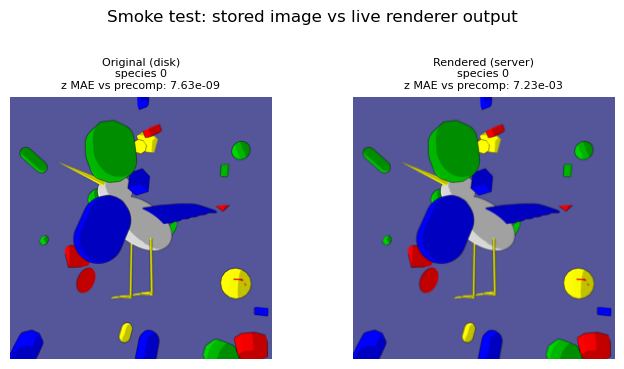

Saved fb_renderer_smoketest_compare.png


In [17]:
# ── Smoke test A: load stored image from disk, verify z matches pre-computed ──
_local_idx = test_idx_by_species[0][0]   # first test image of species 0
_ann       = test_anns[_local_idx]
_class_idx = int(_ann['class_idx'])
_img_path  = FB / 'test' / str(_class_idx) / f'{_local_idx:06d}.png'
_img_disk  = None

if _img_path.exists():
    _img_disk  = Image.open(_img_path).convert('RGB')
    _z_disk, _ = run_through_cbm(_img_disk)
    _gid       = _FUNNYBIRDS_N_TRAIN + _local_idx
    _z_precomp = z_te[id_to_row_te[_gid]]
    _mae_disk  = (_z_disk - _z_precomp).abs().mean().item()
    print(f'Disk image → z MAE vs pre-computed z: {_mae_disk:.6f}  (expected <1e-4)')
else:
    print(f'[skip] Image not on disk: {_img_path}')
    _mae_disk = float('nan')

# ── Smoke test B: render via server ──────────────────────────────────────────
if RENDERER_AVAILABLE:
    _url_example = json_to_url(_ann)
    print(f'\nExample render URL (first 200 chars):\n  {_url_example[:200]}...')

    _img_render = render_ann(_ann)
    _z_render, _p_render = run_through_cbm(_img_render)
    _mae_render = (_z_render - _z_precomp).abs().mean().item() if _img_disk else float('nan')
    print(f'Renderer → z MAE vs pre-computed z: {_mae_render:.6f}  (ideally <0.05)')
    print(f'Renderer top prediction: species {int(_p_render.argmax())}  '
          f'P(species {_class_idx})={_p_render[_class_idx]:.4f}')

    # Pixel difference between disk image and rendered image
    if _img_disk is not None:
        import numpy as np
        _arr_disk   = np.array(_img_disk.resize((256, 256)))
        _arr_render = np.array(_img_render)
        _pixel_mae  = np.abs(_arr_disk.astype(float) - _arr_render.astype(float)).mean()
        print(f'Pixel MAE (disk vs rendered): {_pixel_mae:.2f}  '
              f'(0=identical, <5 is fine, rendering is stochastic in lighting)')

    # ── Display: disk image vs rendered image side by side ──
    ncols = 2 if _img_disk is not None else 1
    fig, axes = plt.subplots(1, ncols, figsize=(ncols * 3.5, 3.5))
    if ncols == 1:
        axes = [axes]
    if _img_disk is not None:
        axes[0].imshow(_img_disk)
        axes[0].set_title(
            f'Original (disk)\nspecies {_class_idx}\n'
            f'z MAE vs precomp: {_mae_disk:.2e}', fontsize=8)
        axes[0].axis('off')
    axes[-1].imshow(_img_render)
    axes[-1].set_title(
        f'Rendered (server)\nspecies {_class_idx}\n'
        f'z MAE vs precomp: {_mae_render:.2e}', fontsize=8)
    axes[-1].axis('off')
    plt.suptitle('Smoke test: stored image vs live renderer output', y=1.04)
    plt.tight_layout()
    plt.savefig('fb_renderer_smoketest_compare.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('Saved fb_renderer_smoketest_compare.png')
else:
    print('[skip] Renderer not available — smoke test B skipped.')
    if _img_disk is not None:
        fig, ax = plt.subplots(figsize=(3.5, 3.5))
        ax.imshow(_img_disk)
        ax.set_title(f'Original (disk) — species {_class_idx}', fontsize=8)
        ax.axis('off')
        plt.tight_layout()
        plt.show()

## 6. Part swap and deletion control helpers

- `swap_part_in_ann(ann, part, new_params)` — returns a copy of `ann` with the
  target part replaced by `new_params` (`{'model': ..., 'color': ...}`).
  Camera, lighting, and background fields are **unchanged** → background preserved.
- `delete_part_in_ann(ann, part)` — sets `{part}_model = ''` (empty = renderer
  treats as absent).  Used for the deletion control ceiling.
- `get_concept_dims(part, var_old, var_new)` — returns `(c_old, c_new)` concept
  indices to track in delta-z.

In [18]:
def swap_part_in_ann(ann: dict, part: str, new_params: dict) -> dict:
    """
    Return a shallow copy of ann with the target part replaced by new_params.
    All camera / lighting / background fields are preserved unchanged.
    """
    cf = dict(ann)                              # shallow copy — all other fields intact
    cf[f'{part}_model'] = new_params['model']
    if part in PARTS_WITH_COLOR:
        cf[f'{part}_color'] = new_params.get('color', '')
    return cf


def delete_part_in_ann(ann: dict, part: str) -> dict:
    """
    Return a copy of ann with the target part removed.
    Empty model string signals the renderer to omit the part entirely
    (same convention as render_interventions.py).
    """
    cf = dict(ann)
    cf[f'{part}_model'] = ''
    if part in PARTS_WITH_COLOR:
        cf[f'{part}_color'] = ''
    return cf


def get_concept_dims(part: str, var_old: int, var_new: int):
    """
    Returns (c_old, c_new): concept vector indices for the old and new variant.
    var_old = species A's original variant index for this part.
    var_new = species B's variant index (the one being swapped in).
    """
    c_old = CONCEPT_TO_IDX.get(f'{part}_{var_old}', -1)
    c_new = CONCEPT_TO_IDX.get(f'{part}_{var_new}', -1)
    return c_old, c_new


print('Defined: swap_part_in_ann  delete_part_in_ann  get_concept_dims')

Defined: swap_part_in_ann  delete_part_in_ann  get_concept_dims


In [19]:
def swap_record_from_ann(
    ann_orig: dict,
    sid_A: int,
    part: str,
    var_old: int,   # A's variant index for this part
    sid_B: int,
    var_new: int,   # B's variant index (being swapped in)
    z_orig: torch.Tensor,    # pre-computed z for this image [26]
) -> dict:
    """
    Render counterfactual (A's params, B's part) through CBM.
    Returns a dict with shift_B, shift_A, delta_z_old, delta_z_new.
    RENDERER_AVAILABLE must be True before calling.
    """
    p_orig   = z_to_probs(z_orig)                            # [50] CPU
    ann_cf   = swap_part_in_ann(ann_orig, part, species_part_params[sid_B][part])
    img_cf   = render_ann(ann_cf)
    z_cf, p_cf = run_through_cbm(img_cf)

    c_old, c_new = get_concept_dims(part, var_old, var_new)

    return {
        'sid_A': sid_A,   'sid_B': sid_B,
        'part': part,
        'var_old': var_old, 'var_new': var_new,
        'shift_B': float(p_cf[sid_B] - p_orig[sid_B]),
        'shift_A': float(p_cf[sid_A] - p_orig[sid_A]),
        'delta_z_old': float(z_cf[c_old] - z_orig[c_old]) if c_old >= 0 else float('nan'),
        'delta_z_new': float(z_cf[c_new] - z_orig[c_new]) if c_new >= 0 else float('nan'),
    }


def deletion_record_from_ann(
    ann_orig: dict,
    sid_A: int,
    part: str,
    z_orig: torch.Tensor,
) -> dict:
    """
    Render deletion counterfactual (part removed entirely).
    drop_A = P_deletion[A] - P_orig[A]  (expected to be negative: losing identity).
    |drop_A| is the ceiling: maximum loss from removing the part entirely.
    """
    p_orig   = z_to_probs(z_orig)
    ann_del  = delete_part_in_ann(ann_orig, part)
    img_del  = render_ann(ann_del)
    _, p_del = run_through_cbm(img_del)

    return {
        'sid_A': sid_A,
        'part': part,
        'drop_A': float(p_del[sid_A] - p_orig[sid_A]),
    }


print('Defined: swap_record_from_ann  deletion_record_from_ann')

Defined: swap_record_from_ann  deletion_record_from_ann


### Renderer visual check — per-part swap and deletion grid

Renders a single base image three ways for each body part:
- **Original** — same parameters as the stored test image
- **Swap** — one part replaced by a donor species' variant
- **Deletion** — that part entirely removed (blank model string)

**What to look for:** only the target part should change between columns.
Camera angle, lighting, background, and all other parts must be identical.

Base species: 0 (funnybird_00)
Donor per part: beak→sp2, eye→sp2, wing→sp1, foot→sp1, tail→sp1
Parts: ['beak', 'eye', 'wing', 'foot', 'tail']
Part variants for base species: beak=3, eye=1, wing=4, foot=0, tail=4
donendering beak ... 
donendering eye ... 
donendering wing ... 
donendering foot ... 
donendering tail ... 
  beak swap  → ΔP(A)=-0.0018  ΔP(B)=+0.0000
  beak delete → ΔP(A)=-0.0030  (ceiling)
  eye swap  → ΔP(A)=+0.0000  ΔP(B)=+0.0000
  eye delete → ΔP(A)=+0.0000  (ceiling)
  wing swap  → ΔP(A)=-0.9192  ΔP(B)=+0.0071
  wing delete → ΔP(A)=-0.1398  (ceiling)
  foot swap  → ΔP(A)=-0.9507  ΔP(B)=+0.0134
  foot delete → ΔP(A)=-0.0075  (ceiling)
  tail swap  → ΔP(A)=-0.0044  ΔP(B)=+0.0001
  tail delete → ΔP(A)=-0.3689  (ceiling)


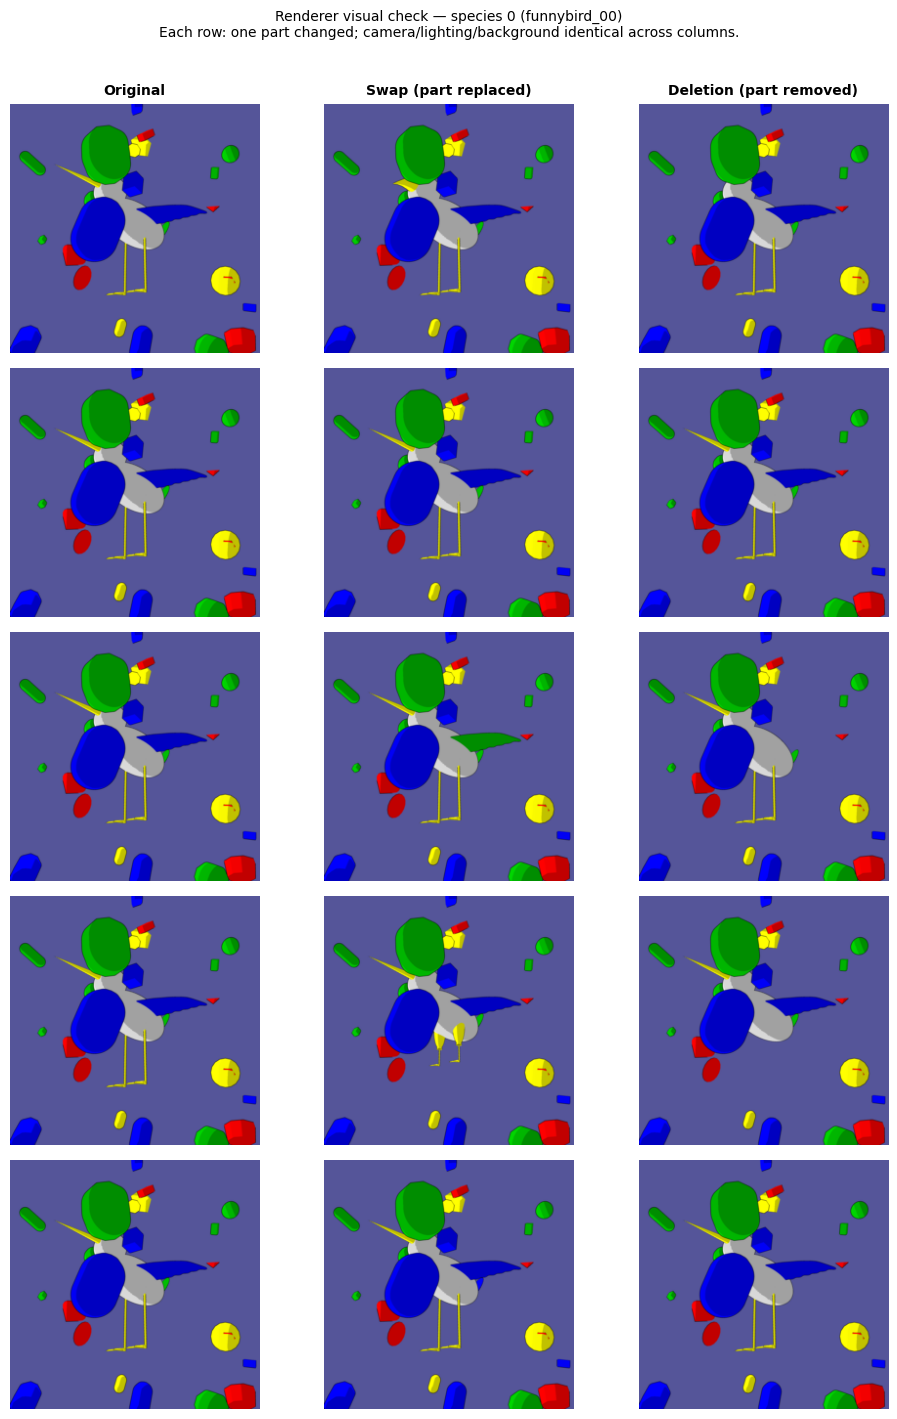


Saved fb_renderer_visual_grid.png
Visual check complete. Verify:
  [1] Only the target part changes between columns (background/camera identical)
  [2] Deletion column is missing that part entirely
  [3] ΔP(A) < 0 after deletion of any part (prediction hurt)
  [4] ΔP(B) > 0 after swap toward B (leakage signal)


In [20]:
if not RENDERER_AVAILABLE:
    print('[skip] Renderer not available — start Node.js server and re-run.')
else:
    _vsid      = 0   # base species for visual check (change freely)
    _v_idx     = test_idx_by_species[_vsid][0]
    _v_ann     = test_anns[_v_idx]
    _v_gid     = _FUNNYBIRDS_N_TRAIN + _v_idx
    _v_z_orig, _v_p_orig = run_through_cbm(render_ann(_v_ann))

    # Find one donor species per part (different variant, first available)
    _donors = {}
    for _part in PARTS:
        _var_A = species_variant_idx[_vsid][_part]
        for _sid_B in range(N_SPECIES):
            if _sid_B != _vsid and species_variant_idx[_sid_B][_part] != _var_A:
                _donors[_part] = _sid_B
                break

    print(f'Base species: {_vsid} ({spname(_vsid)})')
    print(f'Donor per part: ' + ', '.join(f'{p}→sp{d}' for p, d in _donors.items()))
    print(f'Parts: {PARTS}')
    print(f'Part variants for base species: '
          + ', '.join(f'{p}={species_variant_idx[_vsid][p]}' for p in PARTS))

    # ── Render all images (3 per part = 15 total) ───────────────────────────
    _grid = {}  # part → {'orig': img, 'swap': (img, donor_sid), 'del': img}
    for _part in PARTS:
        print(f'  Rendering {_part} ...', end=' ', flush=True)
        _donor = _donors.get(_part)
        _orig  = render_ann(_v_ann)

        _ann_sw = swap_part_in_ann(_v_ann, _part,
                                   species_part_params[_donor][_part]) if _donor else None
        _img_sw = render_ann(_ann_sw) if _ann_sw else None

        _ann_dl = delete_part_in_ann(_v_ann, _part)
        _img_dl = render_ann(_ann_dl)

        _grid[_part] = {'orig': _orig, 'swap': (_img_sw, _donor), 'del': _img_dl}
        print('done')

    # ── Display grid: rows = parts, cols = [original | swap | deletion] ─────
    _nrows = len(PARTS)
    fig, axes = plt.subplots(_nrows, 3, figsize=(10, _nrows * 2.8))
    _col_titles = ['Original', 'Swap (part replaced)', 'Deletion (part removed)']
    for ci, ct in enumerate(_col_titles):
        axes[0, ci].set_title(ct, fontsize=10, fontweight='bold', pad=6)

    for ri, _part in enumerate(PARTS):
        _g      = _grid[_part]
        _color  = PART_COLORS[_part]

        # Left label: part name
        axes[ri, 0].set_ylabel(_part, fontsize=10, rotation=0,
                               ha='right', labelpad=40, color=_color, fontweight='bold')

        # Col 0 — original (same for every row, but rendered fresh to confirm consistency)
        axes[ri, 0].imshow(_g['orig'])
        _pred_orig = int(_v_p_orig.argmax())
        axes[ri, 0].set_xlabel(
            f'pred={_pred_orig} P({_vsid})={_v_p_orig[_vsid]:.3f}', fontsize=7)

        # Col 1 — swap
        _img_sw, _donor = _g['swap']
        if _img_sw is not None:
            axes[ri, 1].imshow(_img_sw)
            _, _p_sw = run_through_cbm(_img_sw)
            _dpA = float(_p_sw[_vsid]   - _v_p_orig[_vsid])
            _dpB = float(_p_sw[_donor]  - _v_p_orig[_donor])
            axes[ri, 1].set_xlabel(
                f'donor=sp{_donor}  ΔP(A)={_dpA:+.3f}  ΔP(B)={_dpB:+.3f}', fontsize=7)
            print(f'  {_part} swap  → ΔP(A)={_dpA:+.4f}  ΔP(B)={_dpB:+.4f}')
        else:
            axes[ri, 1].text(0.5, 0.5, 'no donor', ha='center', va='center',
                             transform=axes[ri, 1].transAxes)

        # Col 2 — deletion
        axes[ri, 2].imshow(_g['del'])
        _, _p_dl = run_through_cbm(_g['del'])
        _dpA_dl = float(_p_dl[_vsid] - _v_p_orig[_vsid])
        axes[ri, 2].set_xlabel(f'ΔP(A)={_dpA_dl:+.3f}  (deletion ceiling)', fontsize=7)
        print(f'  {_part} delete → ΔP(A)={_dpA_dl:+.4f}  (ceiling)')

        for ci in range(3):
            axes[ri, ci].axis('off')
            for spine in axes[ri, ci].spines.values():
                spine.set_edgecolor(_color)
                spine.set_linewidth(1.5)

    plt.suptitle(
        f'Renderer visual check — species {_vsid} ({spname(_vsid)})\n'
        f'Each row: one part changed; camera/lighting/background identical across columns.',
        y=1.01, fontsize=10)
    plt.tight_layout()
    plt.savefig('fb_renderer_visual_grid.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('\nSaved fb_renderer_visual_grid.png')
    print('Visual check complete. Verify:')
    print('  [1] Only the target part changes between columns (background/camera identical)')
    print('  [2] Deletion column is missing that part entirely')
    print('  [3] ΔP(A) < 0 after deletion of any part (prediction hurt)')
    print('  [4] ΔP(B) > 0 after swap toward B (leakage signal)')

## 7. Run renderer swap — tail (primary experiment)

Tail has 9 variants across 50 species; all 5 part-variant dimensions are measured.

**Loop structure:**
- Build all (A, B) pairs where `tail_variant_A ≠ tail_variant_B`
- Forward pass: take `MAX_IMGS_PER_SPECIES` test images of A, re-render with B's tail
  → measure `shift_B` and `delta_z`
- Backward pass: take images of B, re-render with A's tail → measure `shift_A`
- Deletion control: render A's image with tail removed → `drop_A` (ceiling)
- `leakage_sym = 0.5 × (mean_shift_B_fwd + mean_shift_A_bwd)` per pair

In [21]:
# All (A, B) pairs where tail variant differs; ordered (smaller sid first)
tail_swap_pairs = [
    (sid_A, species_variant_idx[sid_A]['tail'],
     sid_B, species_variant_idx[sid_B]['tail'])
    for sid_A, sid_B in combinations(range(N_SPECIES), 2)
    if species_variant_idx[sid_A]['tail'] != species_variant_idx[sid_B]['tail']
]

print(f'Tail-differing pairs: {len(tail_swap_pairs)}')

if MAX_PAIRS_PER_PART is not None and len(tail_swap_pairs) > MAX_PAIRS_PER_PART:
    rng = random.Random(42)
    _run_tail_pairs = rng.sample(tail_swap_pairs, MAX_PAIRS_PER_PART)
    print(f'Sampling {MAX_PAIRS_PER_PART} pairs for this run.')
else:
    _run_tail_pairs = tail_swap_pairs

# Estimate runtime (rough: ~1.5 s per render on CPU Node.js server)
_n_renders = len(_run_tail_pairs) * 2 * MAX_IMGS_PER_SPECIES * 2  # fwd+bwd, swap+del
print(f'Estimated renders: {_n_renders}  (~{_n_renders * 1.5 / 60:.0f} min at 1.5 s each)')

Tail-differing pairs: 1094
Sampling 100 pairs for this run.
Estimated renders: 2000  (~50 min at 1.5 s each)


In [22]:
tail_swap_rows = []
tail_del_rows  = []
_del_done_te   = set()  # (local_idx, part) already deletion-rendered

if not RENDERER_AVAILABLE:
    print('[SKIP] Renderer not available. Start Node.js server and re-run.')
else:
    for sid_A, var_A, sid_B, var_B in tqdm(_run_tail_pairs, desc='tail swaps'):

        # ── Forward: images of A, donate B's tail ────────────────────────────
        for local_idx in test_idx_by_species[sid_A][:MAX_IMGS_PER_SPECIES]:
            gid   = _FUNNYBIRDS_N_TRAIN + local_idx
            row   = id_to_row_te[gid]
            z_orig = z_te[row]

            r = swap_record_from_ann(
                test_anns[local_idx], sid_A, 'tail', var_A, sid_B, var_B, z_orig)
            r['direction'] = 'fwd'
            tail_swap_rows.append(r)

            # Deletion control for this image (once, regardless of pair)
            if (local_idx, 'tail') not in _del_done_te:
                tail_del_rows.append(
                    deletion_record_from_ann(test_anns[local_idx], sid_A, 'tail', z_orig))
                _del_done_te.add((local_idx, 'tail'))

        # ── Backward: images of B, donate A's tail ───────────────────────────
        for local_idx in test_idx_by_species[sid_B][:MAX_IMGS_PER_SPECIES]:
            gid   = _FUNNYBIRDS_N_TRAIN + local_idx
            row   = id_to_row_te[gid]
            z_orig = z_te[row]

            # From B's perspective: B is now 'A', A is the donor 'B'
            r = swap_record_from_ann(
                test_anns[local_idx], sid_B, 'tail', var_B, sid_A, var_A, z_orig)
            r['direction'] = 'bwd'
            tail_swap_rows.append(r)

            if (local_idx, 'tail') not in _del_done_te:
                tail_del_rows.append(
                    deletion_record_from_ann(test_anns[local_idx], sid_B, 'tail', z_orig))
                _del_done_te.add((local_idx, 'tail'))

    print(f'Tail swap rows: {len(tail_swap_rows)}')
    print(f'Deletion rows:  {len(tail_del_rows)}')

tail swaps:   0%|          | 0/100 [00:00<?, ?it/s]

Tail swap rows: 1000
Deletion rows:  245


In [23]:
if tail_swap_rows:
    tail_swap_df = pd.DataFrame(tail_swap_rows)
    tail_del_df  = pd.DataFrame(tail_del_rows)

    # Per-pair symmetric leakage: leakage_sym = 0.5*(mean_shift_B_fwd + mean_shift_A_bwd)
    fwd_agg = (
        tail_swap_df[tail_swap_df['direction'] == 'fwd']
        .groupby(['sid_A', 'sid_B', 'var_old', 'var_new'])
        .agg(shift_B_fwd=('shift_B', 'mean'), shift_A_fwd=('shift_A', 'mean'),
             delta_z_old_mean=('delta_z_old', 'mean'),
             delta_z_new_mean=('delta_z_new', 'mean'))
        .reset_index()
    )
    bwd_agg = (
        tail_swap_df[tail_swap_df['direction'] == 'bwd']
        .groupby(['sid_A', 'sid_B'])
        .agg(shift_B_bwd=('shift_B', 'mean'))
        .reset_index()
        .rename(columns={'sid_A': 'sid_B_orig', 'sid_B': 'sid_A_orig',
                         'shift_B_bwd': 'shift_A_bwd'})
    )
    # Merge: for pair (A, B), fwd has sid_A=A sid_B=B; bwd has sid_A=B sid_B=A
    bwd_agg = bwd_agg.rename(columns={'sid_B_orig': 'sid_A', 'sid_A_orig': 'sid_B'})
    tail_pair_df = fwd_agg.merge(bwd_agg, on=['sid_A', 'sid_B'], how='left')
    tail_pair_df['leakage_sym'] = 0.5 * (
        tail_pair_df['shift_B_fwd'] + tail_pair_df['shift_A_bwd'].fillna(0))
    tail_pair_df['part'] = 'tail'

    print(f'Tail pair-level results: {len(tail_pair_df)} pairs')
    print(f'  leakage_sym  mean={tail_pair_df["leakage_sym"].mean():.4f}'
          f'  median={tail_pair_df["leakage_sym"].median():.4f}'
          f'  max={tail_pair_df["leakage_sym"].max():.4f}')
    print(f'  delta_z_old  mean={tail_pair_df["delta_z_old_mean"].mean():.4f}  '
          f'(expected < 0: old concept dim falls)')
    print(f'  delta_z_new  mean={tail_pair_df["delta_z_new_mean"].mean():.4f}  '
          f'(expected > 0: new concept dim rises)')
    del_ceiling = tail_del_df.groupby('sid_A')['drop_A'].mean().abs().mean()
    print(f'  deletion ceiling |drop_A|: {del_ceiling:.4f}')
    display(tail_pair_df.sort_values('leakage_sym', ascending=False).head(10))
else:
    print('[no results] Renderer was not available.')

Tail pair-level results: 100 pairs
  leakage_sym  mean=0.0075  median=0.0001  max=0.1788
  delta_z_old  mean=-0.5481  (expected < 0: old concept dim falls)
  delta_z_new  mean=0.3875  (expected > 0: new concept dim rises)
  deletion ceiling |drop_A|: 0.1313


,sid_A,sid_B,var_old,var_new,shift_B_fwd,shift_A_fwd,delta_z_old_mean,delta_z_new_mean,shift_A_bwd,leakage_sym,part
52,13,27,8,3,0.357642,-0.816146,-0.973513,0.813784,NaN,0.178821,tail
48,11,49,5,3,0.207538,-0.483905,-0.760118,0.610631,NaN,0.103769,tail
47,11,45,5,6,0.198545,-0.560664,-0.830043,0.502214,NaN,0.099272,tail
8,2,6,4,8,0.141661,-0.314108,-0.679418,0.813503,NaN,0.070831,tail
23,5,14,5,6,0.105529,-0.229261,-0.932405,0.163931,NaN,0.052765,tail
44,11,25,5,3,0.076098,-0.483905,-0.760118,0.610631,NaN,0.038049,tail
63,16,24,7,3,0.058309,-0.303087,-0.508550,0.585905,NaN,0.029155,tail
34,8,11,0,5,0.056826,-0.658359,-0.999266,0.953287,NaN,0.028413,tail
69,19,44,4,6,0.045794,-0.063635,-0.684968,0.194085,NaN,0.022897,tail
77,22,41,1,6,0.037820,-0.321567,-0.451052,0.364484,NaN,0.018910,tail


## 8. Extend to all body parts

Run the same forward/backward/deletion loop for `beak`, `eye`, `wing`, and `foot`.
Results are appended to `all_swap_rows` and `all_del_rows` alongside tail.

In [ ]:
all_pair_dfs = [tail_pair_df] if tail_swap_rows else []
all_del_rows = list(tail_del_rows) if tail_del_rows else []

OTHER_PARTS = [p for p in PARTS if p != 'tail']

if not RENDERER_AVAILABLE:
    print('[SKIP] Renderer not available.')
else:
    for part in OTHER_PARTS:
        _pairs = [
            (sid_A, species_variant_idx[sid_A][part],
             sid_B, species_variant_idx[sid_B][part])
            for sid_A, sid_B in combinations(range(N_SPECIES), 2)
            if species_variant_idx[sid_A][part] != species_variant_idx[sid_B][part]
        ]
        if MAX_PAIRS_PER_PART is not None and len(_pairs) > MAX_PAIRS_PER_PART:
            rng = random.Random(42)
            _pairs = rng.sample(_pairs, MAX_PAIRS_PER_PART)
        print(f'{part}: {len(_pairs)} pairs')

        _swap_rows, _del_rows = [], []
        _del_done  = set()
        for sid_A, var_A, sid_B, var_B in tqdm(_pairs, desc=part):
            for local_idx in test_idx_by_species[sid_A][:MAX_IMGS_PER_SPECIES]:
                gid    = _FUNNYBIRDS_N_TRAIN + local_idx
                z_orig = z_te[id_to_row_te[gid]]
                r = swap_record_from_ann(
                    test_anns[local_idx], sid_A, part, var_A, sid_B, var_B, z_orig)
                r['direction'] = 'fwd'
                _swap_rows.append(r)
                if (local_idx, part) not in _del_done:
                    _del_rows.append(
                        deletion_record_from_ann(test_anns[local_idx], sid_A, part, z_orig))
                    _del_done.add((local_idx, part))

            for local_idx in test_idx_by_species[sid_B][:MAX_IMGS_PER_SPECIES]:
                gid    = _FUNNYBIRDS_N_TRAIN + local_idx
                z_orig = z_te[id_to_row_te[gid]]
                r = swap_record_from_ann(
                    test_anns[local_idx], sid_B, part, var_B, sid_A, var_A, z_orig)
                r['direction'] = 'bwd'
                _swap_rows.append(r)
                if (local_idx, part) not in _del_done:
                    _del_rows.append(
                        deletion_record_from_ann(test_anns[local_idx], sid_B, part, z_orig))
                    _del_done.add((local_idx, part))

        if _swap_rows:
            _df = pd.DataFrame(_swap_rows)
            _fwd = (_df[_df['direction']=='fwd']
                    .groupby(['sid_A','sid_B','var_old','var_new'])
                    .agg(shift_B_fwd=('shift_B','mean'), shift_A_fwd=('shift_A','mean'),
                         delta_z_old_mean=('delta_z_old','mean'),
                         delta_z_new_mean=('delta_z_new','mean'))
                    .reset_index())
            _bwd = (_df[_df['direction']=='bwd']
                    .groupby(['sid_A','sid_B'])
                    .agg(shift_B_bwd=('shift_B','mean'))
                    .reset_index()
                    .rename(columns={'sid_A':'sid_B','sid_B':'sid_A',
                                     'shift_B_bwd':'shift_A_bwd'}))
            _pair = _fwd.merge(_bwd, on=['sid_A','sid_B'], how='left')
            _pair['leakage_sym'] = 0.5 * (
                _pair['shift_B_fwd'] + _pair['shift_A_bwd'].fillna(0))
            _pair['part'] = part
            all_pair_dfs.append(_pair)
            all_del_rows.extend(_del_rows)
            print(f'  {part} leakage_sym mean={_pair["leakage_sym"].mean():.4f}')

beak: 100 pairs


beak:   0%|          | 0/100 [00:00<?, ?it/s]

  beak leakage_sym mean=0.0251
eye: 100 pairs


eye:   0%|          | 0/100 [00:00<?, ?it/s]

  eye leakage_sym mean=0.0405
wing: 100 pairs


wing:   0%|          | 0/100 [00:00<?, ?it/s]

## 9. Aggregate results

In [33]:
if all_pair_dfs:
    swap_df  = pd.concat(all_pair_dfs, ignore_index=True)
    del_df   = pd.DataFrame(all_del_rows)

    swap_df.to_csv('fb_cbm_renderer_swap.csv', index=False)
    del_df.to_csv( 'fb_cbm_renderer_deletion.csv', index=False)
    print(f'Saved fb_cbm_renderer_swap.csv ({len(swap_df)} pair rows)')
    print(f'Saved fb_cbm_renderer_deletion.csv ({len(del_df)} rows)')
    display(swap_df.groupby('part')['leakage_sym']
            .describe().round(4))
else:
    print('[no results] Run renderer cells first.')

Saved fb_cbm_renderer_swap.csv (500 pair rows)
Saved fb_cbm_renderer_deletion.csv (1235 rows)


,count,mean,std,min,25%,50%,75%,max
part,,,,,,,,
beak,100.0,0.0251,0.0948,0.0,0.0001,0.0004,0.0026,0.6185
eye,100.0,0.0405,0.1392,0.0,0.0000,0.0003,0.0025,0.8659
foot,100.0,0.0559,0.1238,0.0,0.0004,0.0020,0.0321,0.6599
tail,100.0,0.0075,0.0245,0.0,0.0000,0.0001,0.0014,0.1788
wing,100.0,0.0546,0.1240,0.0,0.0004,0.0025,0.0382,0.9206


In [34]:
if all_pair_dfs:
    # Deletion ceiling per part: mean |drop_A| across all deletion images
    del_ceil = (del_df.groupby('part')['drop_A']
                .apply(lambda x: x.abs().mean())
                .reset_index(name='deletion_ceiling'))

    part_summary = (
        swap_df.groupby('part', as_index=False)
        .agg(
            n_pairs        = ('leakage_sym', 'size'),
            leakage_mean   = ('leakage_sym', 'mean'),
            leakage_sem    = ('leakage_sym', lambda x: x.std() / (len(x)**0.5)),
            leakage_max    = ('leakage_sym', 'max'),
            shift_B_fwd    = ('shift_B_fwd', 'mean'),
            delta_z_old    = ('delta_z_old_mean', 'mean'),
            delta_z_new    = ('delta_z_new_mean', 'mean'),
            frac_positive  = ('leakage_sym', lambda x: (x > 0).mean()),
        )
        .merge(del_ceil, on='part', how='left')
        .sort_values('leakage_mean', ascending=False)
        .reset_index(drop=True)
    )
    print('Per-part summary:')
    display(part_summary)

Per-part summary:


,part,n_pairs,leakage_mean,leakage_sem,leakage_max,shift_B_fwd,delta_z_old,delta_z_new,frac_positive,deletion_ceiling
0,foot,100,0.055917,0.012382,0.659869,0.068682,-0.902088,0.930043,1.0,0.194336
1,wing,100,0.054633,0.012397,0.920588,0.053667,-0.924264,0.888490,1.0,0.202257
2,eye,100,0.040500,0.013921,0.865889,0.042688,-0.825609,0.800392,1.0,0.093983
3,beak,100,0.025142,0.009483,0.618512,0.025131,-0.698185,0.645383,1.0,0.082964
4,tail,100,0.007520,0.002455,0.178821,0.015039,-0.548131,0.387514,1.0,0.139351


## 10. Delta-z analysis — did the bottleneck detect the part change?

For each swap, we measure:
- `delta_z_old` = z_cf[old_concept_dim] − z_orig[old_concept_dim]  → **expected < 0**  
  (the old part variant's concept dim should fall when that variant is removed)
- `delta_z_new` = z_cf[new_concept_dim] − z_orig[new_concept_dim]  → **expected > 0**  
  (the new part variant's concept dim should rise when it is inserted)

If both expectations hold, the bottleneck is detecting the part change correctly.
The key downstream question: does a large `delta_z_new` correlate with a large `shift_B`?

In [35]:
if all_pair_dfs:
    dz_summary = (
        swap_df.groupby('part', as_index=False)
        .agg(
            delta_z_old_mean = ('delta_z_old_mean', 'mean'),
            delta_z_old_std  = ('delta_z_old_mean', 'std'),
            delta_z_new_mean = ('delta_z_new_mean', 'mean'),
            delta_z_new_std  = ('delta_z_new_mean', 'std'),
        )
        .sort_values('delta_z_new_mean', ascending=False)
    )
    print('Delta-z per part (mean over all pairs):')
    print('  delta_z_old < 0 means old variant concept dim fell (correct)')
    print('  delta_z_new > 0 means new variant concept dim rose  (correct)')
    display(dz_summary)

    # Pearson correlation: delta_z_new vs shift_B (per-pair, tail only)
    _tail = swap_df[swap_df['part'] == 'tail'].dropna(
        subset=['delta_z_new_mean', 'shift_B_fwd'])
    if len(_tail) > 4:
        r, p = stats.pearsonr(_tail['delta_z_new_mean'], _tail['shift_B_fwd'])
        print(f'\nTail: corr(delta_z_new, shift_B_fwd) = {r:.3f}  p={p:.3e}')
        print('  >0: concepts that rise in the bottleneck also shift prediction toward B')

Delta-z per part (mean over all pairs):
  delta_z_old < 0 means old variant concept dim fell (correct)
  delta_z_new > 0 means new variant concept dim rose  (correct)


,part,delta_z_old_mean,delta_z_old_std,delta_z_new_mean,delta_z_new_std
2,foot,-0.902088,0.118668,0.930043,0.114662
4,wing,-0.924264,0.100221,0.888490,0.170990
1,eye,-0.825609,0.164624,0.800392,0.192028
0,beak,-0.698185,0.221804,0.645383,0.281437
3,tail,-0.548131,0.247667,0.387514,0.293039



Tail: corr(delta_z_new, shift_B_fwd) = 0.227  p=2.339e-02
  >0: concepts that rise in the bottleneck also shift prediction toward B


## 11. Diagnostic plots

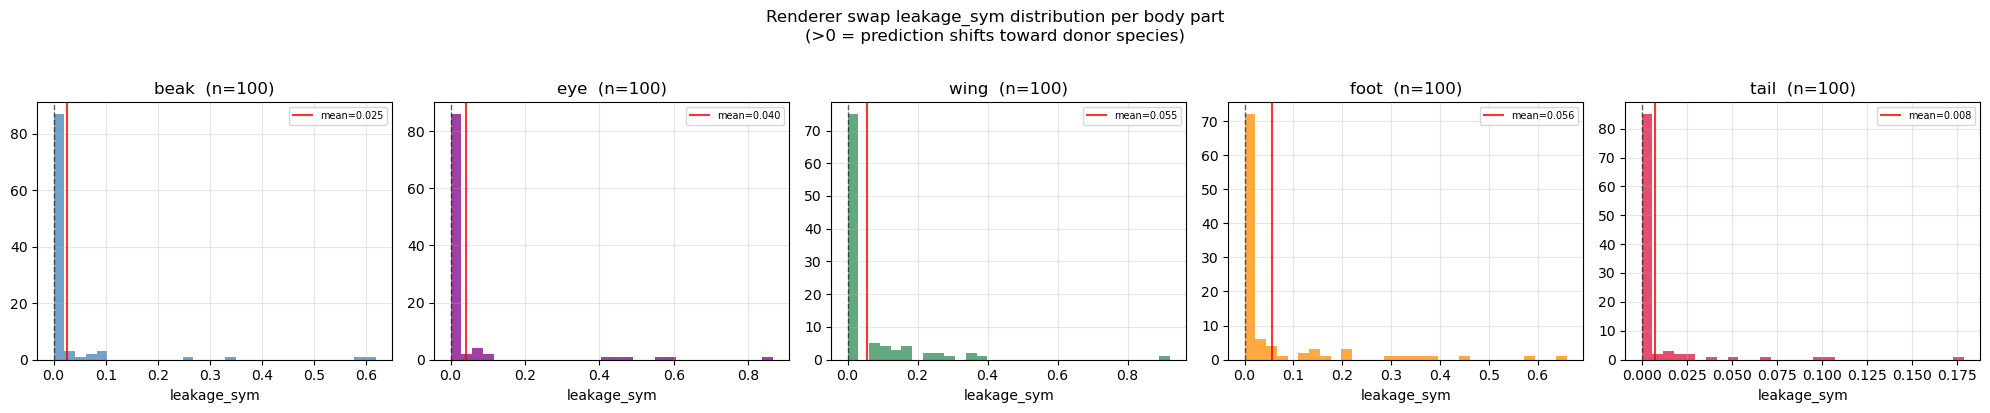

Saved fb_renderer_swap_leakage_hist.png


In [36]:
if all_pair_dfs:
    parts_present = swap_df['part'].unique()
    ncols = len(parts_present)
    fig, axes = plt.subplots(1, ncols, figsize=(4 * ncols, 4), sharey=False)
    if ncols == 1:
        axes = [axes]

    for ax, part in zip(axes, PARTS):  # use canonical PARTS order
        if part not in parts_present:
            ax.set_visible(False)
            continue
        vals = swap_df[swap_df['part'] == part]['leakage_sym'].dropna()
        ax.hist(vals, bins=30, color=PART_COLORS[part], alpha=0.75, edgecolor='none')
        ax.axvline(0, color='black', ls='--', alpha=0.6, lw=1)
        ax.axvline(vals.mean(), color='red', ls='-', alpha=0.8, lw=1.5,
                   label=f'mean={vals.mean():.3f}')
        ax.set_xlabel('leakage_sym')
        ax.set_title(f'{part}  (n={len(vals)})')
        ax.legend(fontsize=7)
        ax.grid(True, alpha=0.3)

    plt.suptitle('Renderer swap leakage_sym distribution per body part\n'
                 '(>0 = prediction shifts toward donor species)', y=1.02)
    plt.tight_layout()
    plt.savefig('fb_renderer_swap_leakage_hist.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('Saved fb_renderer_swap_leakage_hist.png')

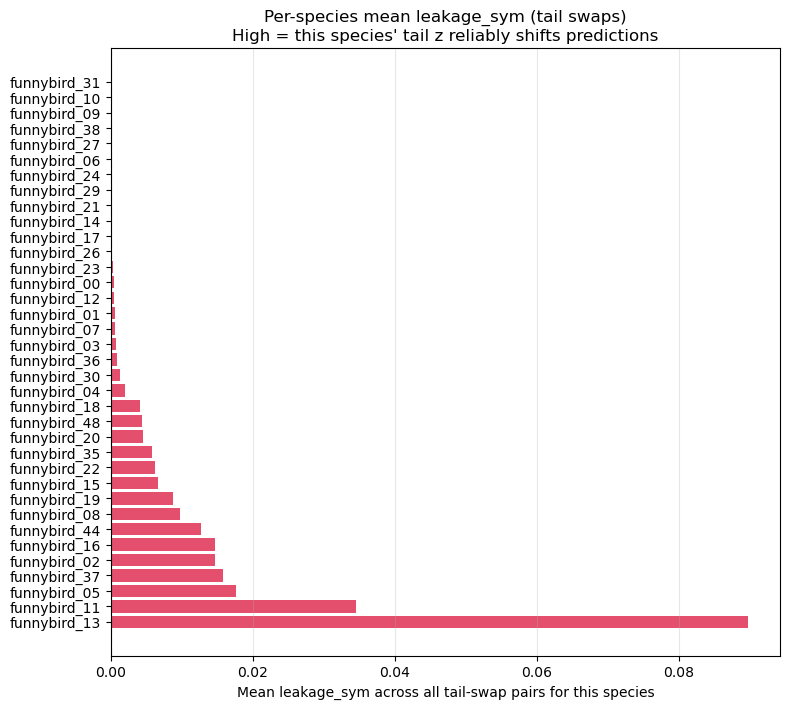

Saved fb_renderer_swap_per_species_tail.png


In [37]:
if all_pair_dfs and 'tail' in swap_df['part'].values:
    _tail_df = swap_df[swap_df['part'] == 'tail'].copy()

    # Average leakage per species A across all its pairs
    sp_leak = (
        _tail_df.groupby('sid_A')['leakage_sym']
        .mean().reset_index(name='mean_leakage')
        .sort_values('mean_leakage', ascending=False)
    )
    sp_leak['name'] = sp_leak['sid_A'].map(spname)

    fig, ax = plt.subplots(figsize=(8, max(4, len(sp_leak) * 0.2)))
    ax.barh(sp_leak['name'], sp_leak['mean_leakage'], color='crimson', alpha=0.75)
    ax.axvline(0, color='gray', ls='--', alpha=0.6)
    ax.set_xlabel('Mean leakage_sym across all tail-swap pairs for this species')
    ax.set_title('Per-species mean leakage_sym (tail swaps)\n'
                 'High = this species\' tail z reliably shifts predictions')
    ax.grid(True, axis='x', alpha=0.3)
    plt.tight_layout()
    plt.savefig('fb_renderer_swap_per_species_tail.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('Saved fb_renderer_swap_per_species_tail.png')

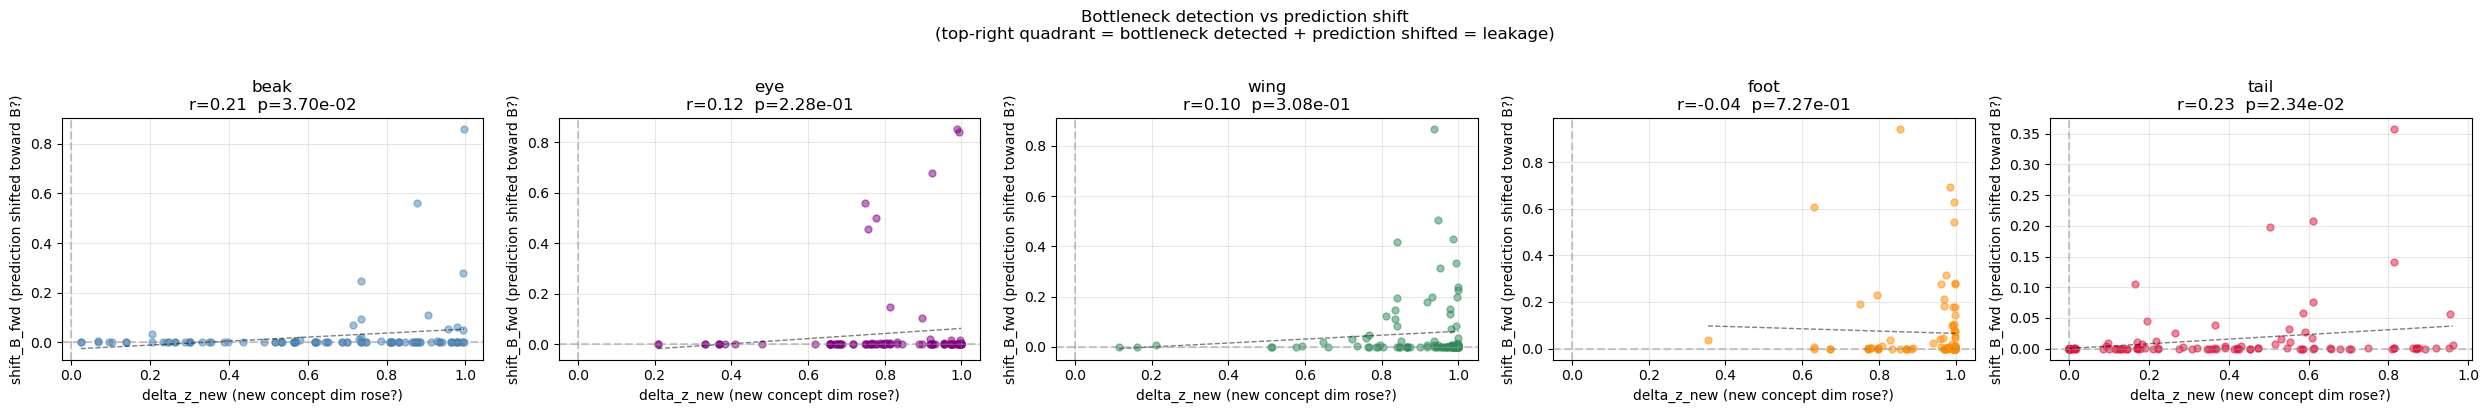

Saved fb_renderer_swap_dz_vs_shift.png


In [38]:
if all_pair_dfs:
    fig, axes = plt.subplots(1, len([p for p in PARTS if p in swap_df['part'].values]),
                             figsize=(5 * len(PARTS), 4))
    if not hasattr(axes, '__len__'):
        axes = [axes]
    _ax_iter = iter(axes)

    for part in PARTS:
        if part not in swap_df['part'].values:
            continue
        ax = next(_ax_iter)
        sub = swap_df[swap_df['part'] == part].dropna(
            subset=['delta_z_new_mean', 'shift_B_fwd'])
        ax.scatter(sub['delta_z_new_mean'], sub['shift_B_fwd'],
                   color=PART_COLORS[part], s=25, alpha=0.5)
        if len(sub) > 4:
            r, pv = stats.pearsonr(sub['delta_z_new_mean'], sub['shift_B_fwd'])
            m, b  = np.polyfit(sub['delta_z_new_mean'], sub['shift_B_fwd'], 1)
            xs    = np.array([sub['delta_z_new_mean'].min(),
                              sub['delta_z_new_mean'].max()])
            ax.plot(xs, m * xs + b, 'k--', alpha=0.5, lw=1)
            ax.set_title(f'{part}\nr={r:.2f}  p={pv:.2e}')
        else:
            ax.set_title(part)
        ax.set_xlabel('delta_z_new (new concept dim rose?)')
        ax.set_ylabel('shift_B_fwd (prediction shifted toward B?)')
        ax.axhline(0, color='gray', ls='--', alpha=0.4)
        ax.axvline(0, color='gray', ls='--', alpha=0.4)
        ax.grid(True, alpha=0.3)

    plt.suptitle('Bottleneck detection vs prediction shift\n'
                 '(top-right quadrant = bottleneck detected + prediction shifted = leakage)', y=1.02)
    plt.tight_layout()
    plt.savefig('fb_renderer_swap_dz_vs_shift.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('Saved fb_renderer_swap_dz_vs_shift.png')

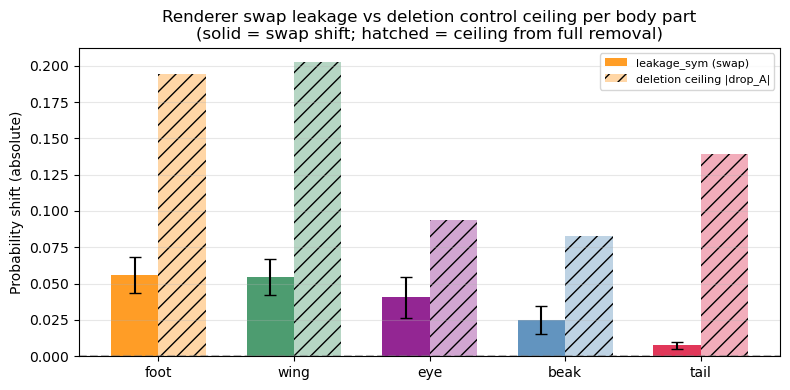

Saved fb_renderer_swap_vs_deletion.png


In [39]:
if all_pair_dfs:
    fig, ax = plt.subplots(figsize=(8, 4))
    x_labels = list(part_summary['part'])
    x        = np.arange(len(x_labels))
    w        = 0.35

    bars_swap = ax.bar(
        x - w/2,
        part_summary['leakage_mean'],
        w,
        yerr=part_summary['leakage_sem'],
        color=[PART_COLORS[p] for p in x_labels],
        alpha=0.85, capsize=4, label='leakage_sym (swap)',
    )
    bars_del = ax.bar(
        x + w/2,
        part_summary['deletion_ceiling'],
        w,
        color=[PART_COLORS[p] for p in x_labels],
        alpha=0.35, hatch='//', label='deletion ceiling |drop_A|',
    )

    ax.set_xticks(x)
    ax.set_xticklabels(x_labels)
    ax.axhline(0, color='gray', ls='--', alpha=0.5)
    ax.set_ylabel('Probability shift (absolute)')
    ax.set_title('Renderer swap leakage vs deletion control ceiling per body part\n'
                 '(solid = swap shift; hatched = ceiling from full removal)')
    ax.legend(fontsize=8)
    ax.grid(True, axis='y', alpha=0.3)
    plt.tight_layout()
    plt.savefig('fb_renderer_swap_vs_deletion.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('Saved fb_renderer_swap_vs_deletion.png')

## 12. Summary

### What this notebook measures

| Measure | Variable | Interpretation |
|---|---|---|
| Prediction shift toward donor | `shift_B_fwd` | Did the prediction move toward species B after inserting B's part? |
| Symmetric leakage | `leakage_sym` | Both directions confirm: z_C carries species signal |
| Bottleneck detection | `delta_z_new` | Did the CBM actually notice the part change? |
| Deletion ceiling | `deletion_ceiling` | Max possible shift: how much does removal hurt P(A)? |

### Interpreting leakage_sym

`leakage_sym > 0` means: inserting species B's part into species A's image
systematically raises P(B) — the concept bottleneck z carries information about
*which species produced a given part*, not just *which part variant is present*.

A strong result has **both** `delta_z_new > 0` (bottleneck detected the swap) **and**
`shift_B > 0` (that detection translated into a species-identity prediction shift).
If `delta_z_new ≈ 0` but `shift_B > 0`, the shift is coming from residual
backbone signal leaking around the bottleneck rather than through it.

### Comparison to deletion ceiling

If `leakage_sym ≈ deletion_ceiling`, the swapped part is providing as much
species-B signal as removal costs species-A signal — maximum leakage.
If `leakage_sym << deletion_ceiling`, the part change is only weakly informative
compared to having the part present at all.

### Next steps

- **ANOVA (Experiment 2):** formal F-test for between-species variance in z_C.
- **CKA (Experiment 3):** single number comparing geometry of z to species vs concept.
- Target pairs for this renderer experiment are best chosen *after* ANOVA identifies
  which parts have highest between-species z_C variance.

In [40]:
if all_pair_dfs:
    print('=== EXPERIMENT 1 RENDERER SWAP SUMMARY ===')
    print(f'Parts tested:    {sorted(swap_df["part"].unique())}')
    print(f'Total pair rows: {len(swap_df)}')
    print()
    for _, row in part_summary.iterrows():
        print(f'{row["part"]:6s}  leakage_sym={row["leakage_mean"]:+.4f} '
              f'(±{row["leakage_sem"]:.4f})  '
              f'ceiling={row["deletion_ceiling"]:.4f}  '
              f'frac_positive={row["frac_positive"]:.2%}  '
              f'n={int(row["n_pairs"])}')
    print()
    _best = part_summary.iloc[0]
    print(f'Most leaky part: {_best["part"]}  '
          f'(leakage_sym={_best["leakage_mean"]:+.4f}, '
          f'{_best["frac_positive"]:.0%} of pairs positive)')
else:
    print('No results — renderer was not available during this run.')
    print('Re-run Cells 29–32 after starting the Node.js server.')

=== EXPERIMENT 1 RENDERER SWAP SUMMARY ===
Parts tested:    ['beak', 'eye', 'foot', 'tail', 'wing']
Total pair rows: 500

foot    leakage_sym=+0.0559 (±0.0124)  ceiling=0.1943  frac_positive=100.00%  n=100
wing    leakage_sym=+0.0546 (±0.0124)  ceiling=0.2023  frac_positive=100.00%  n=100
eye     leakage_sym=+0.0405 (±0.0139)  ceiling=0.0940  frac_positive=100.00%  n=100
beak    leakage_sym=+0.0251 (±0.0095)  ceiling=0.0830  frac_positive=100.00%  n=100
tail    leakage_sym=+0.0075 (±0.0025)  ceiling=0.1394  frac_positive=100.00%  n=100

Most leaky part: foot  (leakage_sym=+0.0559, 100% of pairs positive)


In [41]:
def z_ordering_record(
    ann_orig: dict,
    sid_src: int,
    part: str,
    var_src: int,
    sid_donor: int,
    var_donor: int,
    z_orig: torch.Tensor,
) -> dict:
    c_src   = CONCEPT_TO_IDX[f'{part}_{var_src}']
    c_donor = CONCEPT_TO_IDX[f'{part}_{var_donor}']

    ann_cf = swap_part_in_ann(ann_orig, part, species_part_params[sid_donor][part])
    img_cf = render_ann(ann_cf)
    z_cf, p_cf = run_through_cbm(img_cf)

    z_new  = float(z_cf[c_donor])
    z_old  = float(z_cf[c_src])
    margin = z_new - z_old

    z_gt          = z_orig.clone()
    z_gt[c_donor] = 1.0
    z_gt[c_src]   = 0.0
    p_gt          = z_to_probs(z_gt)

    return {
        'sid_src': sid_src, 'sid_donor': sid_donor, 'part': part,
        'var_src': var_src, 'var_donor': var_donor,
        'c_src': c_src, 'c_donor': c_donor,
        'z_new': z_new, 'z_old': z_old,
        'z_new_orig': float(z_orig[c_donor]),
        'z_old_orig': float(z_orig[c_src]),
        'margin': margin,
        'ordering_correct': bool(margin > 0),
        'p_cf_donor': float(p_cf[sid_donor]),
        'p_gt_donor': float(p_gt[sid_donor]),
        'leakage': float(p_gt[sid_donor]) - float(p_cf[sid_donor]),
    }

print('Defined: z_ordering_record')

Defined: z_ordering_record


In [46]:
tail_z_pairs = [
    (sid_A, species_variant_idx[sid_A]['tail'],
     sid_B, species_variant_idx[sid_B]['tail'])
    for sid_A, sid_B in combinations(range(N_SPECIES), 2)
    if species_variant_idx[sid_A]['tail'] != species_variant_idx[sid_B]['tail']
]

if MAX_PAIRS_PER_PART is not None and len(tail_z_pairs) > MAX_PAIRS_PER_PART:
    _run_z_tail = random.Random(42).sample(tail_z_pairs, MAX_PAIRS_PER_PART)
else:
    _run_z_tail = tail_z_pairs

_n_renders = len(_run_z_tail) * 2 * MAX_IMGS_PER_SPECIES
print(f'Tail z-ordering pairs: {len(tail_z_pairs)}  running: {len(_run_z_tail)}')
print(f'Estimated renders: {_n_renders}  (~{_n_renders * 1.5 / 60:.0f} min at 1.5 s each)')

Tail z-ordering pairs: 1094  running: 100
Estimated renders: 1000  (~25 min at 1.5 s each)


In [49]:
import subprocess
print(subprocess.run(['ss', '-tlnp'], capture_output=True, text=True).stdout)

State  Recv-Q Send-Q Local Address:Port  Peer Address:PortProcess                                     
LISTEN 0      2048         0.0.0.0:111        0.0.0.0:*                                               
LISTEN 0      128          0.0.0.0:22         0.0.0.0:*                                               
LISTEN 0      2048         0.0.0.0:730        0.0.0.0:*                                               
LISTEN 0      100        127.0.0.1:48393      0.0.0.0:*    users:(("python",pid=438289,fd=35))        
LISTEN 0      100        127.0.0.1:41485      0.0.0.0:*    users:(("python",pid=1762804,fd=9))        
LISTEN 0      100        127.0.0.1:42385      0.0.0.0:*    users:(("python",pid=1601432,fd=27))       
LISTEN 0      100        127.0.0.1:43525      0.0.0.0:*    users:(("python",pid=438289,fd=11))        
LISTEN 0      2048         0.0.0.0:6818       0.0.0.0:*                                               
LISTEN 0      100        127.0.0.1:40321      0.0.0.0:*    users:(("pytho

In [50]:
print(subprocess.run(['lsof', '-i', ':8081'], capture_output=True, text=True).stdout)

COMMAND     PID   USER   FD   TYPE    DEVICE SIZE/OFF NODE NAME
python  1762804 cr7998   69u  IPv4 211912757      0t0  TCP localhost:57146->localhost:tproxy (ESTABLISHED)
node    1762879 cr7998   18u  IPv6 211608553      0t0  TCP *:tproxy (LISTEN)
node    1762879 cr7998   19u  IPv6 211909854      0t0  TCP localhost:tproxy->localhost:57146 (ESTABLISHED)
node    1762879 cr7998   23u  IPv6 211912765      0t0  TCP localhost6:tproxy->localhost6:41802 (ESTABLISHED)
node    1762879 cr7998   25u  IPv6 211910192      0t0  TCP localhost6:tproxy->localhost6:41808 (ESTABLISHED)
node    1762879 cr7998   26u  IPv6 211910193      0t0  TCP localhost6:tproxy->localhost6:41818 (ESTABLISHED)
node    1762879 cr7998   27u  IPv6 211910195      0t0  TCP localhost6:tproxy->localhost6:41828 (ESTABLISHED)
node    1762879 cr7998   28u  IPv6 211910197      0t0  TCP localhost6:tproxy->localhost6:41832 (ESTABLISHED)
node    1762879 cr7998   29u  IPv6 211910199      0t0  TCP localhost6:tproxy->localhost6:41840 (ESTA

In [51]:
RENDERER_AVAILABLE = True

# Confirm with a real render (will take a few seconds)
import requests
try:
    r = requests.get(
        'http://localhost:8081/render?render_mode=default'
        '&beak_model=beak01.glb&eye_model=eye01.glb'
        '&foot_model=foot01.glb&tail_model=tail01.glb&tail_color=red'
        '&wing_model=wing01.glb&wing_color=red'
        '&camera_distance=300&camera_pitch=0&camera_roll=0'
        '&light_distance=300&light_pitch=0&light_roll=0',
        timeout=30
    )
    print(r.status_code, len(r.content), "bytes")
except Exception as e:
    print(type(e).__name__, e)

200 12028 bytes


In [53]:
tail_z_rows = []

if not RENDERER_AVAILABLE:
    print('[SKIP] Renderer not available.')
else:
    for sid_A, var_A, sid_B, var_B in tqdm(_run_z_tail, desc='tail z-ordering'):
        for local_idx in test_idx_by_species[sid_A][:MAX_IMGS_PER_SPECIES]:
            gid = _FUNNYBIRDS_N_TRAIN + local_idx
            row = id_to_row_te.get(gid)
            if row is None: continue
            r = z_ordering_record(test_anns[local_idx], sid_A, 'tail', var_A, sid_B, var_B, z_te[row])
            r['direction'] = 'fwd'; tail_z_rows.append(r)

        for local_idx in test_idx_by_species[sid_B][:MAX_IMGS_PER_SPECIES]:
            gid = _FUNNYBIRDS_N_TRAIN + local_idx
            row = id_to_row_te.get(gid)
            if row is None: continue
            r = z_ordering_record(test_anns[local_idx], sid_B, 'tail', var_B, sid_A, var_A, z_te[row])
            r['direction'] = 'bwd'; tail_z_rows.append(r)

    print(f'Tail z-ordering rows: {len(tail_z_rows)}')
    if tail_z_rows:
        _df = pd.DataFrame(tail_z_rows)
        print(f'  ordering_correct: {_df["ordering_correct"].mean():.3%}')
        print(f'  mean margin:      {_df["margin"].mean():+.4f}')
        print(f'  mean leakage:     {_df["leakage"].mean():+.4f}')

tail z-ordering:   0%|          | 0/100 [00:00<?, ?it/s]

Tail z-ordering rows: 1000
  ordering_correct: 47.600%
  mean margin:      +0.0574
  mean leakage:     +0.0124


Parallen render server attempt

In [54]:
import subprocess, time, os

RENDERER_PORTS = [8081, 8082, 8083, 8084]  # one per core you want to use
_renderer_procs = {}

for port in RENDERER_PORTS:
    if port == 8081:
        # already running — skip
        _renderer_procs[port] = None
        continue
    env = {**os.environ, 'PORT': str(port)}
    p = subprocess.Popen(['node', 'server.js'], cwd=str(RENDERER_DIR),
                         env=env, stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL)
    _renderer_procs[port] = p

time.sleep(6)  # let them all start

# Verify
alive_ports = []
for port in RENDERER_PORTS:
    try:
        r = requests.get(f'http://localhost:{port}/render?render_mode=default'
            '&beak_model=beak01.glb&eye_model=eye01.glb&foot_model=foot01.glb'
            '&tail_model=tail01.glb&tail_color=red&wing_model=wing01.glb&wing_color=red'
            '&camera_distance=300&camera_pitch=0&camera_roll=0'
            '&light_distance=300&light_pitch=0&light_roll=0', timeout=20)
        if r.status_code == 200:
            alive_ports.append(port)
            print(f'port {port}: OK')
    except Exception as e:
        print(f'port {port}: {e}')

print(f'Live ports: {alive_ports}')

port 8081: OK
port 8082: HTTPConnectionPool(host='localhost', port=8082): Max retries exceeded with url: /render?render_mode=default&beak_model=beak01.glb&eye_model=eye01.glb&foot_model=foot01.glb&tail_model=tail01.glb&tail_color=red&wing_model=wing01.glb&wing_color=red&camera_distance=300&camera_pitch=0&camera_roll=0&light_distance=300&light_pitch=0&light_roll=0 (Caused by NewConnectionError('<urllib3.connection.HTTPConnection object at 0x7fd793a76d10>: Failed to establish a new connection: [Errno 111] Connection refused'))
port 8083: HTTPConnectionPool(host='localhost', port=8083): Max retries exceeded with url: /render?render_mode=default&beak_model=beak01.glb&eye_model=eye01.glb&foot_model=foot01.glb&tail_model=tail01.glb&tail_color=red&wing_model=wing01.glb&wing_color=red&camera_distance=300&camera_pitch=0&camera_roll=0&light_distance=300&light_pitch=0&light_roll=0 (Caused by NewConnectionError('<urllib3.connection.HTTPConnection object at 0x7fd793a75fc0>: Failed to establish a ne

In [55]:
all_z_rows = list(tail_z_rows)

if not RENDERER_AVAILABLE:
    print('[SKIP] Renderer not available.')
else:
    for part in [p for p in PARTS if p != 'tail']:
        _pairs = [
            (sid_A, species_variant_idx[sid_A][part],
             sid_B, species_variant_idx[sid_B][part])
            for sid_A, sid_B in combinations(range(N_SPECIES), 2)
            if species_variant_idx[sid_A][part] != species_variant_idx[sid_B][part]
        ]
        if MAX_PAIRS_PER_PART is not None and len(_pairs) > MAX_PAIRS_PER_PART:
            _pairs = random.Random(42).sample(_pairs, MAX_PAIRS_PER_PART)
        print(f'{part}: {len(_pairs)} pairs')

        for sid_A, var_A, sid_B, var_B in tqdm(_pairs, desc=part):
            for local_idx in test_idx_by_species[sid_A][:MAX_IMGS_PER_SPECIES]:
                gid = _FUNNYBIRDS_N_TRAIN + local_idx
                row = id_to_row_te.get(gid)
                if row is None: continue
                r = z_ordering_record(test_anns[local_idx], sid_A, part, var_A, sid_B, var_B, z_te[row])
                r['direction'] = 'fwd'; all_z_rows.append(r)
            for local_idx in test_idx_by_species[sid_B][:MAX_IMGS_PER_SPECIES]:
                gid = _FUNNYBIRDS_N_TRAIN + local_idx
                row = id_to_row_te.get(gid)
                if row is None: continue
                r = z_ordering_record(test_anns[local_idx], sid_B, part, var_B, sid_A, var_A, z_te[row])
                r['direction'] = 'bwd'; all_z_rows.append(r)

        _part_df = pd.DataFrame([r for r in all_z_rows if r['part'] == part])
        print(f'  ordering_correct: {_part_df["ordering_correct"].mean():.3%}  mean margin: {_part_df["margin"].mean():+.4f}')

beak: 100 pairs


beak:   0%|          | 0/100 [00:00<?, ?it/s]

  ordering_correct: 75.700%  mean margin: +0.4781
eye: 100 pairs


eye:   0%|          | 0/100 [00:00<?, ?it/s]

  ordering_correct: 86.800%  mean margin: +0.7154
wing: 100 pairs


wing:   0%|          | 0/100 [00:00<?, ?it/s]

  ordering_correct: 96.500%  mean margin: +0.8395
foot: 100 pairs


foot:   0%|          | 0/100 [00:00<?, ?it/s]

  ordering_correct: 96.600%  mean margin: +0.8836
